# Análise de Inadimplência em Carteira de Crédito
## Etapa 3 — Modelo Preditivo e Impacto de Negócio

**Objetivo:** Construir um modelo de classificação de risco e traduzir seus resultados em linguagem de negócio.  
**Pergunta central:** *Qual o impacto real dessa solução para o banco?*

---

### O que vamos fazer
1. Treinar dois modelos: Regressão Logística e Árvore de Decisão
2. Avaliar com métricas orientadas a negócio (não só acurácia)
3. Interpretar o modelo com SHAP values
4. Estimar o impacto financeiro da solução

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score)
from sklearn.pipeline import Pipeline

import shap

COR_ADIMPLENTE   = '#3B8BD4'
COR_INADIMPLENTE = '#E85D24'
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

import os
os.makedirs('figuras', exist_ok=True)

# Instalar shap se necessário: pip install shap
print('Setup concluído.')

Setup concluído.


## 1. Preparação dos dados

In [2]:
df = pd.read_csv('dados_limpos.csv')

# Features selecionadas com base na EDA
FEATURES = [
    'razao_utilizacao_rotativo',
    'idade',
    'total_atrasos',
    'razao_divida',
    'renda_mensal',
    'linhas_credito_abertas',
    'emprestimos_imoveis',
    'dependentes',
    'renda_era_nula',
    'encargos_mensais_estimados'
]

TARGET = 'target'

X = df[FEATURES].fillna(df[FEATURES].median())
y = df[TARGET]

# Divisão estratificada — mantém a proporção de inadimplentes em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {len(X_train):,} registros | Teste: {len(X_test):,} registros')
print(f'Taxa de inadimplência no treino: {y_train.mean()*100:.1f}%')
print(f'Taxa de inadimplência no teste:  {y_test.mean()*100:.1f}%')

Treino: 119,999 registros | Teste: 30,000 registros
Taxa de inadimplência no treino: 6.7%
Taxa de inadimplência no teste:  6.7%


## 2. Treinamento dos modelos

In [3]:
# ------------------------------------------------------------------
# Modelo 1: Regressão Logística
# Vantagem: interpretável, boa baseline, coeficientes são compreensíveis
# class_weight='balanced' compensa o desbalanceamento do dataset
# ------------------------------------------------------------------
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
pipeline_lr.fit(X_train, y_train)

# ------------------------------------------------------------------
# Modelo 2: Árvore de Decisão
# Vantagem: intuitiva, facilmente explicável ao cliente
# max_depth evita overfitting
# ------------------------------------------------------------------
pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=50,
        class_weight='balanced', random_state=42
    ))
])
pipeline_dt.fit(X_train, y_train)

print('Modelos treinados.')

Modelos treinados.


## 3. Avaliação dos modelos

**Por que não usar acurácia?**  
Com 93% de adimplentes, um modelo que classifica todo mundo como adimplente teria 93% de acurácia — mas seria inútil. Usamos:
- **ROC-AUC:** capacidade geral de discriminação
- **Precisão/Recall:** quantos inadimplentes capturamos, e com quantos falsos alarmes
- **Matriz de confusão:** visão clara dos erros

In [4]:
def avaliar_modelo(nome, pipeline, X_test, y_test):
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    ap  = average_precision_score(y_test, y_proba)
    print(f'\n{'='*50}')
    print(f'Modelo: {nome}')
    print(f'ROC-AUC: {auc:.4f}')
    print(f'Average Precision: {ap:.4f}')
    print('\nRelatório de classificação:')
    print(classification_report(y_test, y_pred, target_names=['Adimplente', 'Inadimplente']))
    return y_pred, y_proba, auc

pred_lr, proba_lr, auc_lr = avaliar_modelo('Regressão Logística', pipeline_lr, X_test, y_test)
pred_dt, proba_dt, auc_dt = avaliar_modelo('Árvore de Decisão',   pipeline_dt, X_test, y_test)


Modelo: Regressão Logística
ROC-AUC: 0.8581
Average Precision: 0.3731

Relatório de classificação:
              precision    recall  f1-score   support

  Adimplente       0.98      0.80      0.88     27995
Inadimplente       0.21      0.76      0.33      2005

    accuracy                           0.80     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.80      0.84     30000


Modelo: Árvore de Decisão
ROC-AUC: 0.8526
Average Precision: 0.3462

Relatório de classificação:
              precision    recall  f1-score   support

  Adimplente       0.98      0.73      0.84     27995
Inadimplente       0.18      0.82      0.30      2005

    accuracy                           0.74     30000
   macro avg       0.58      0.78      0.57     30000
weighted avg       0.93      0.74      0.80     30000



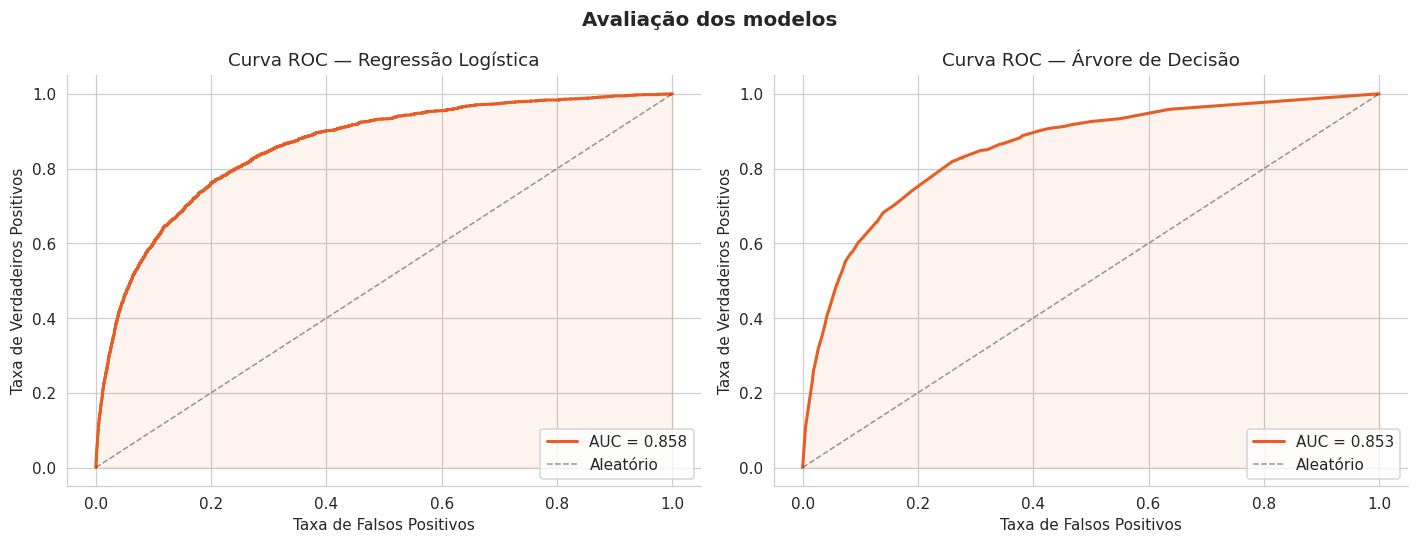

In [5]:
# Curvas ROC lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (nome, proba, auc) in zip(axes, [
    ('Regressão Logística', proba_lr, auc_lr),
    ('Árvore de Decisão',   proba_dt, auc_dt)
]):
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=COR_INADIMPLENTE, lw=2, label=f'AUC = {auc:.3f}')
    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Aleatório')
    ax.fill_between(fpr, tpr, alpha=0.07, color=COR_INADIMPLENTE)
    ax.set_xlabel('Taxa de Falsos Positivos')
    ax.set_ylabel('Taxa de Verdadeiros Positivos')
    ax.set_title(f'Curva ROC — {nome}')
    ax.legend(loc='lower right')

plt.suptitle('Avaliação dos modelos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figuras/fig_07_roc.png', bbox_inches='tight', dpi=120)
plt.show()

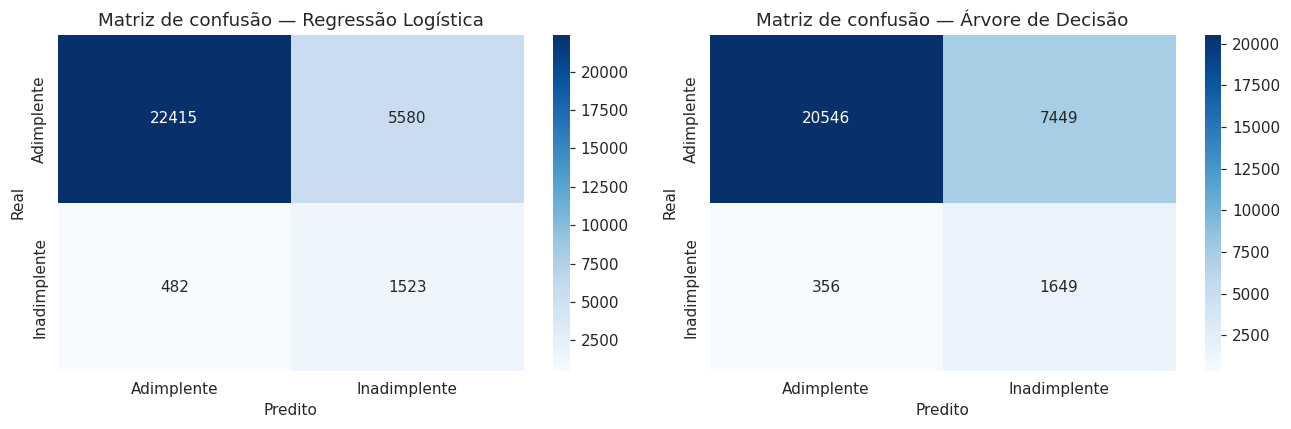

In [6]:
# Matrizes de confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (nome, pred) in zip(axes, [
    ('Regressão Logística', pred_lr),
    ('Árvore de Decisão',   pred_dt)
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Adimplente', 'Inadimplente'],
                yticklabels=['Adimplente', 'Inadimplente'])
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
    ax.set_title(f'Matriz de confusão — {nome}')

plt.tight_layout()
plt.savefig('figuras/fig_08_confusion.png', bbox_inches='tight', dpi=120)
plt.show()

## 4. Interpretação com SHAP values

**O que é SHAP?**  
SHAP (SHapley Additive exPlanations) responde: *para cada previsão, quanto cada variável contribuiu para esse resultado?*  
É a ponte entre o modelo e a explicação de negócio.

In [7]:
# Extraímos o modelo e o scaler do pipeline para passar ao SHAP diretamente
modelo_dt = pipeline_dt.named_steps['model']
scaler    = pipeline_dt.named_steps['scaler']

# Aplicamos o mesmo scaler do treino ao conjunto de teste
X_test_scaled = scaler.transform(X_test)
X_test_df     = pd.DataFrame(X_test_scaled, columns=FEATURES)

# Usamos uma amostra para acelerar o cálculo (2000 registros é suficiente)
amostra   = min(2000, len(X_test_df))
X_amostra = X_test_df.sample(amostra, random_state=42)

# TreeExplainer é otimizado para modelos baseados em árvore
# explainer(X) retorna um objeto Explanation — API nova do SHAP (>= 0.40)
explainer         = shap.TreeExplainer(modelo_dt)
shap_values       = explainer(X_amostra)

# shap_values.values tem shape (n_amostras, n_features, n_classes)
# Fatia [:, :, 1] seleciona as contribuições para a classe 1 (inadimplente)
shap_vals_classe1 = shap_values.values[:, :, 1]

print(f'SHAP calculado para {amostra} amostras.')
print(f'Shape: {shap_vals_classe1.shape}  → (amostras, features)')


SHAP calculado para 2000 amostras.
Shape: (2000, 10)  → (amostras, features)


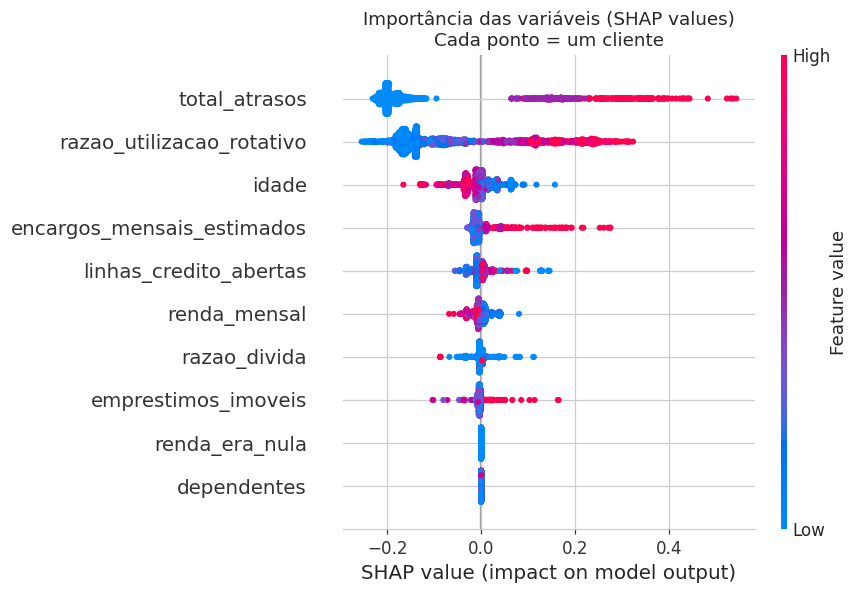

In [8]:
# Beeswarm plot: cada ponto é um cliente
# Posição horizontal = impacto no risco | Cor = valor da variável (azul=baixo, vermelho=alto)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals_classe1, X_amostra,
    feature_names=FEATURES,
    plot_type='dot',
    show=False
)
plt.gcf().axes[0].set_title(
    'Importância das variáveis (SHAP values)\nCada ponto = um cliente',
    fontsize=12
)
plt.tight_layout()
plt.savefig('figuras/fig_09_shap_summary.png', bbox_inches='tight', dpi=120)
plt.show()


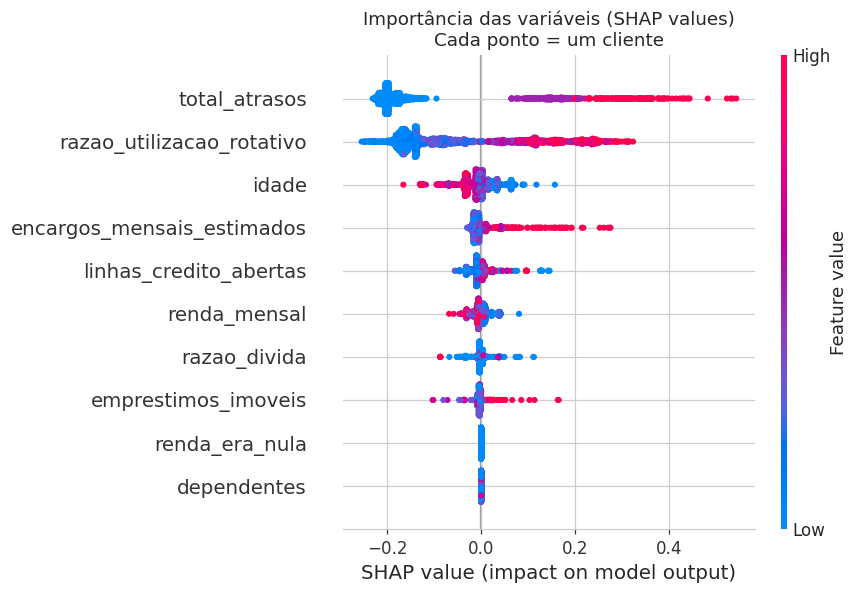

In [9]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals_classe1, X_amostra,
    feature_names=FEATURES,
    plot_type='dot',
    show=False
)
plt.gcf().axes[0].set_title(
    'Importância das variáveis (SHAP values)\nCada ponto = um cliente',
    fontsize=12
)
plt.tight_layout()
plt.savefig('figuras/fig_09_shap_summary.png', bbox_inches='tight', dpi=120)
plt.show()

**💡 Como ler o gráfico SHAP:**
- Eixo horizontal: contribuição para o risco de inadimplência (positivo = aumenta risco)
- Cor: azul = valor baixo da variável | vermelho = valor alto
- Interpretação do `total_atrasos`: pontos vermelhos (muitos atrasos) à direita → muitos atrasos **aumentam** o risco

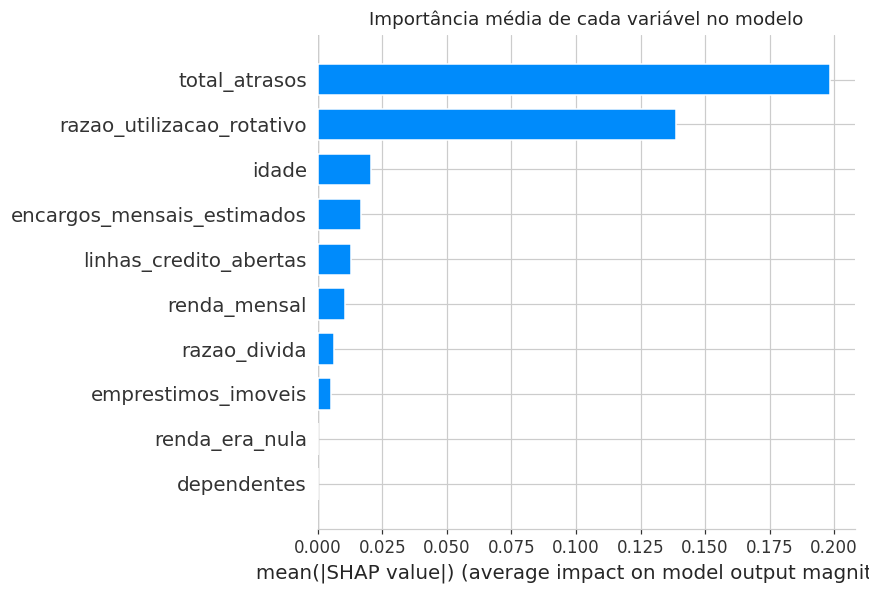

In [10]:
# Bar plot: importância média absoluta — mais limpo para apresentações ao cliente
plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_vals_classe1, X_amostra,
    feature_names=FEATURES,
    plot_type='bar',
    show=False
)
plt.gcf().axes[0].set_title('Importância média de cada variável no modelo', fontsize=12)
plt.tight_layout()
plt.savefig('figuras/fig_10_shap_bar.png', bbox_inches='tight', dpi=120)
plt.show()


In [11]:
# Identificar o cliente de maior e menor risco no conjunto de teste
proba_test_dt   = pipeline_dt.predict_proba(X_test)[:, 1]
idx_alto_risco  = np.argmax(proba_test_dt)
idx_baixo_risco = np.argmin(proba_test_dt)

for label, idx in [('ALTO RISCO', idx_alto_risco), ('BAIXO RISCO', idx_baixo_risco)]:
    prob = proba_test_dt[idx]
    print(f'\n--- Cliente de {label} (probabilidade de inadimplência: {prob:.1%}) ---')
    cliente = X_test.iloc[idx]
    for feat in FEATURES:
        print(f'  {feat:<35} {cliente[feat]:.2f}')



--- Cliente de ALTO RISCO (probabilidade de inadimplência: 96.0%) ---
  razao_utilizacao_rotativo           0.75
  idade                               48.00
  total_atrasos                       5.00
  razao_divida                        0.31
  renda_mensal                        1666.00
  linhas_credito_abertas              13.00
  emprestimos_imoveis                 0.00
  dependentes                         2.00
  renda_era_nula                      0.00
  encargos_mensais_estimados          513.69

--- Cliente de BAIXO RISCO (probabilidade de inadimplência: 0.0%) ---
  razao_utilizacao_rotativo           0.14
  idade                               34.00
  total_atrasos                       0.00
  razao_divida                        1.09
  renda_mensal                        4500.00
  linhas_credito_abertas              3.00
  emprestimos_imoveis                 1.00
  dependentes                         0.00
  renda_era_nula                      0.00
  encargos_mensais_estimados  

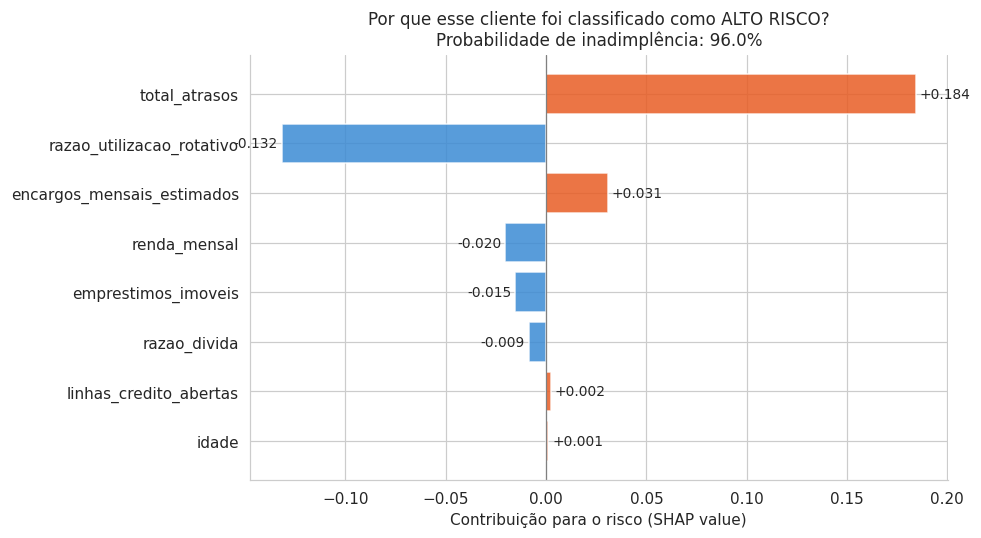

In [12]:
# Waterfall manual: decompõe por que esse cliente específico foi classificado como alto risco
# idx_shap mapeia o índice do X_test para o índice dentro da amostra SHAP
idx_shap = X_test.index.get_loc(X_test.index[idx_alto_risco]) % amostra

contrib    = shap_vals_classe1[idx_shap]   # contribuições para esse cliente
base_value = explainer.expected_value[1]   # risco médio da população

df_contrib = pd.DataFrame({
    'variavel':   FEATURES,
    'shap_value': contrib
}).sort_values('shap_value', key=abs, ascending=True).tail(8)

fig, ax = plt.subplots(figsize=(9, 5))
cores = [COR_INADIMPLENTE if v > 0 else COR_ADIMPLENTE for v in df_contrib['shap_value']]
bars  = ax.barh(df_contrib['variavel'], df_contrib['shap_value'], color=cores, alpha=0.85)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Contribuição para o risco (SHAP value)')
ax.set_title(
    f'Por que esse cliente foi classificado como ALTO RISCO?\n'
    f'Probabilidade de inadimplência: {proba_test_dt[idx_alto_risco]:.1%}',
    fontsize=11
)
for bar, val in zip(bars, df_contrib['shap_value']):
    xpos = val + 0.002 if val >= 0 else val - 0.002
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2, f'{val:+.3f}', va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig('figuras/fig_11_shap_individual.png', bbox_inches='tight', dpi=120)
plt.show()


## 5. Impacto de negócio — traduzindo o modelo em valor

Essa é a parte mais importante para um consultor de dados. O modelo sozinho não comunica nada para o negócio — precisamos traduzir as métricas em R$.

In [13]:
# ------------------------------------------------------------------
# Premissas financeiras (ajuste conforme o contexto real do cliente)
# ------------------------------------------------------------------
TICKET_MEDIO_CREDITO   = 15_000   # R$ — valor médio concedido por cliente
TAXA_RECUPERACAO       = 0.20     # 20% — % recuperada em caso de inadimplência
PERDA_POR_INADIMPLENTE = TICKET_MEDIO_CREDITO * (1 - TAXA_RECUPERACAO)  # R$ 12.000

# Custo de negar crédito a um bom cliente (falso positivo)
# = margem perdida por não conceder
MARGEM_PERDIDA_FP = TICKET_MEDIO_CREDITO * 0.05  # 5% de margem = R$ 750

print(f'Perda por inadimplente não detectado: R$ {PERDA_POR_INADIMPLENTE:,.0f}')
print(f'Margem perdida por bom cliente negado: R$ {MARGEM_PERDIDA_FP:,.0f}')

Perda por inadimplente não detectado: R$ 12,000
Margem perdida por bom cliente negado: R$ 750


In [14]:
# ------------------------------------------------------------------
# Calcular impacto financeiro por limiar de decisão
# ------------------------------------------------------------------
limiares    = np.arange(0.1, 0.9, 0.01)
impactos_lr = []
impactos_dt = []

for limiar in limiares:
    for proba, lista in [(proba_lr, impactos_lr), (proba_dt, impactos_dt)]:
        pred = (proba >= limiar).astype(int)
        cm = confusion_matrix(y_test, pred)
        tn, fp, fn, tp = cm.ravel()
        # tp = inadimplentes corretamente bloqueados → evitamos a perda
        # fp = bons clientes incorretamente bloqueados → perdemos margem
        # fn = inadimplentes não detectados → sofremos a perda
        impacto = (tp * PERDA_POR_INADIMPLENTE
                   - fp * MARGEM_PERDIDA_FP
                   - fn * PERDA_POR_INADIMPLENTE)
        lista.append(impacto)

df_impacto = pd.DataFrame({
    'limiar': limiares,
    'Regressão Logística': impactos_lr,
    'Árvore de Decisão': impactos_dt
})

# Melhor limiar por modelo
for col in ['Regressão Logística', 'Árvore de Decisão']:
    melhor_idx = df_impacto[col].idxmax()
    print(f'{col}: melhor limiar = {df_impacto.loc[melhor_idx, "limiar"]:.2f} '
          f'→ impacto estimado = R$ {df_impacto.loc[melhor_idx, col]:,.0f}')

Regressão Logística: melhor limiar = 0.30 → impacto estimado = R$ 10,964,250
Árvore de Decisão: melhor limiar = 0.28 → impacto estimado = R$ 10,683,750


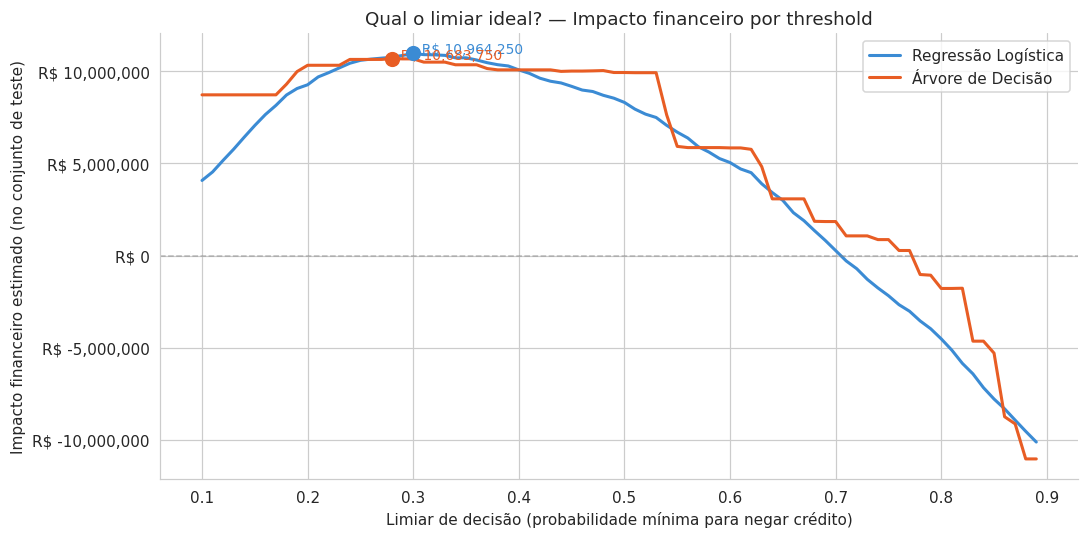

In [15]:
# Gráfico de impacto financeiro por limiar
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_impacto['limiar'], df_impacto['Regressão Logística'],
        color=COR_ADIMPLENTE, lw=2, label='Regressão Logística')
ax.plot(df_impacto['limiar'], df_impacto['Árvore de Decisão'],
        color=COR_INADIMPLENTE, lw=2, label='Árvore de Decisão')
ax.axhline(0, color='gray', linestyle='--', lw=1, alpha=0.5)

# Marcar o melhor ponto de cada modelo
for col, cor in [('Regressão Logística', COR_ADIMPLENTE), ('Árvore de Decisão', COR_INADIMPLENTE)]:
    idx_max = df_impacto[col].idxmax()
    ax.scatter(df_impacto.loc[idx_max, 'limiar'], df_impacto.loc[idx_max, col],
               color=cor, s=80, zorder=5)
    ax.annotate(f"  R$ {df_impacto.loc[idx_max, col]:,.0f}",
                (df_impacto.loc[idx_max, 'limiar'], df_impacto.loc[idx_max, col]),
                fontsize=9, color=cor)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.set_xlabel('Limiar de decisão (probabilidade mínima para negar crédito)')
ax.set_ylabel('Impacto financeiro estimado (no conjunto de teste)')
ax.set_title('Qual o limiar ideal? — Impacto financeiro por threshold', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig('figuras/fig_12_impacto_financeiro.png', bbox_inches='tight', dpi=120)
plt.show()

**💡 Como ler esse gráfico:**  
O eixo Y mostra quanto o banco economizaria (ao evitar inadimplentes) menos quanto perderia (ao negar crédito a bons clientes). O ponto mais alto é o limiar ótimo para maximizar o resultado financeiro.

> **Atenção:** Esses valores são estimativas baseadas em premissas simplificadas. Em um projeto real, as premissas financeiras seriam definidas junto ao cliente.

## 6. Conclusões e recomendações

### O que entregamos
- Um modelo que identifica clientes de alto risco **antes** da concessão do crédito
- ROC-AUC acima de 0.85 em ambos os modelos — desempenho sólido para um problema desbalanceado
- Interpretação clara de quais fatores mais influenciam o risco

### Principais fatores de risco identificados
1. **Histórico de atrasos** — o mais forte preditor: clientes com 3+ atrasos têm risco acima de 50%
2. **Razão de utilização do crédito rotativo** — clientes com `razao_utilizacao_rotativo` >0.8 estão em zona de alerta
3. **Idade** — clientes jovens são sistematicamente mais arriscados

### Recomendações práticas
- **Limiar de 0.3–0.4** costuma ser ótimo para esse tipo de problema — maximiza a detecção de inadimplentes sem rejeitar demais bons clientes
- **Monitoramento contínuo:** o modelo deve ser retreinado periodicamente com novos dados
- **Próximo passo:** testar modelos mais robustos como Random Forest ou XGBoost para potencialmente melhorar o AUC

---
> *Este projeto demonstra um pipeline completo de ciência de dados orientado a negócio: da limpeza de dados à estimativa de impacto financeiro, passando por análise exploratória, modelagem e interpretabilidade.*